# The Quest for Causality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import MaxNLocator
from matplotlib import ticker


In [2]:
# Changing the font to something a bit more professional for all graphs 
plt.rcParams["font.family"] = "Arial"

In [3]:
# Manually adding data from Table 1.1

DonutDS = pd.DataFrame({
    "Obs": np.arange(1, 14),  #np.arange(a,b) makes a series of numbers from a to b-1
    
    "Name": [
        "Homer", "Marge", "Lisa", "Bart", "Comic Book Guy",
        "Mr. Burns", "Smithers", "Chief Wiggum",
        "Principal Skinner", "Rev. Lovejoy",
        "Ned Flanders", "Patty", "Selma"],
        
    "Donuts per week": [14, 0, 0, 5, 20, 0.75, 0.25, 16, 3, 2, 0.8, 5, 4],
    "Weight": [275, 141, 70, 75, 310, 80, 160, 263, 205, 185, 170, 155, 145]
}).set_index("Obs")

display(DonutDS)

,Name,Donuts per week,Weight
Obs,,,
1,Homer,14.00,275
2,Marge,0.00,141
3,Lisa,0.00,70
4,Bart,5.00,75
5,Comic Book Guy,20.00,310
6,Mr. Burns,0.75,80
7,Smithers,0.25,160
8,Chief Wiggum,16.00,263
9,Principal Skinner,3.00,205


### Figure 1.2

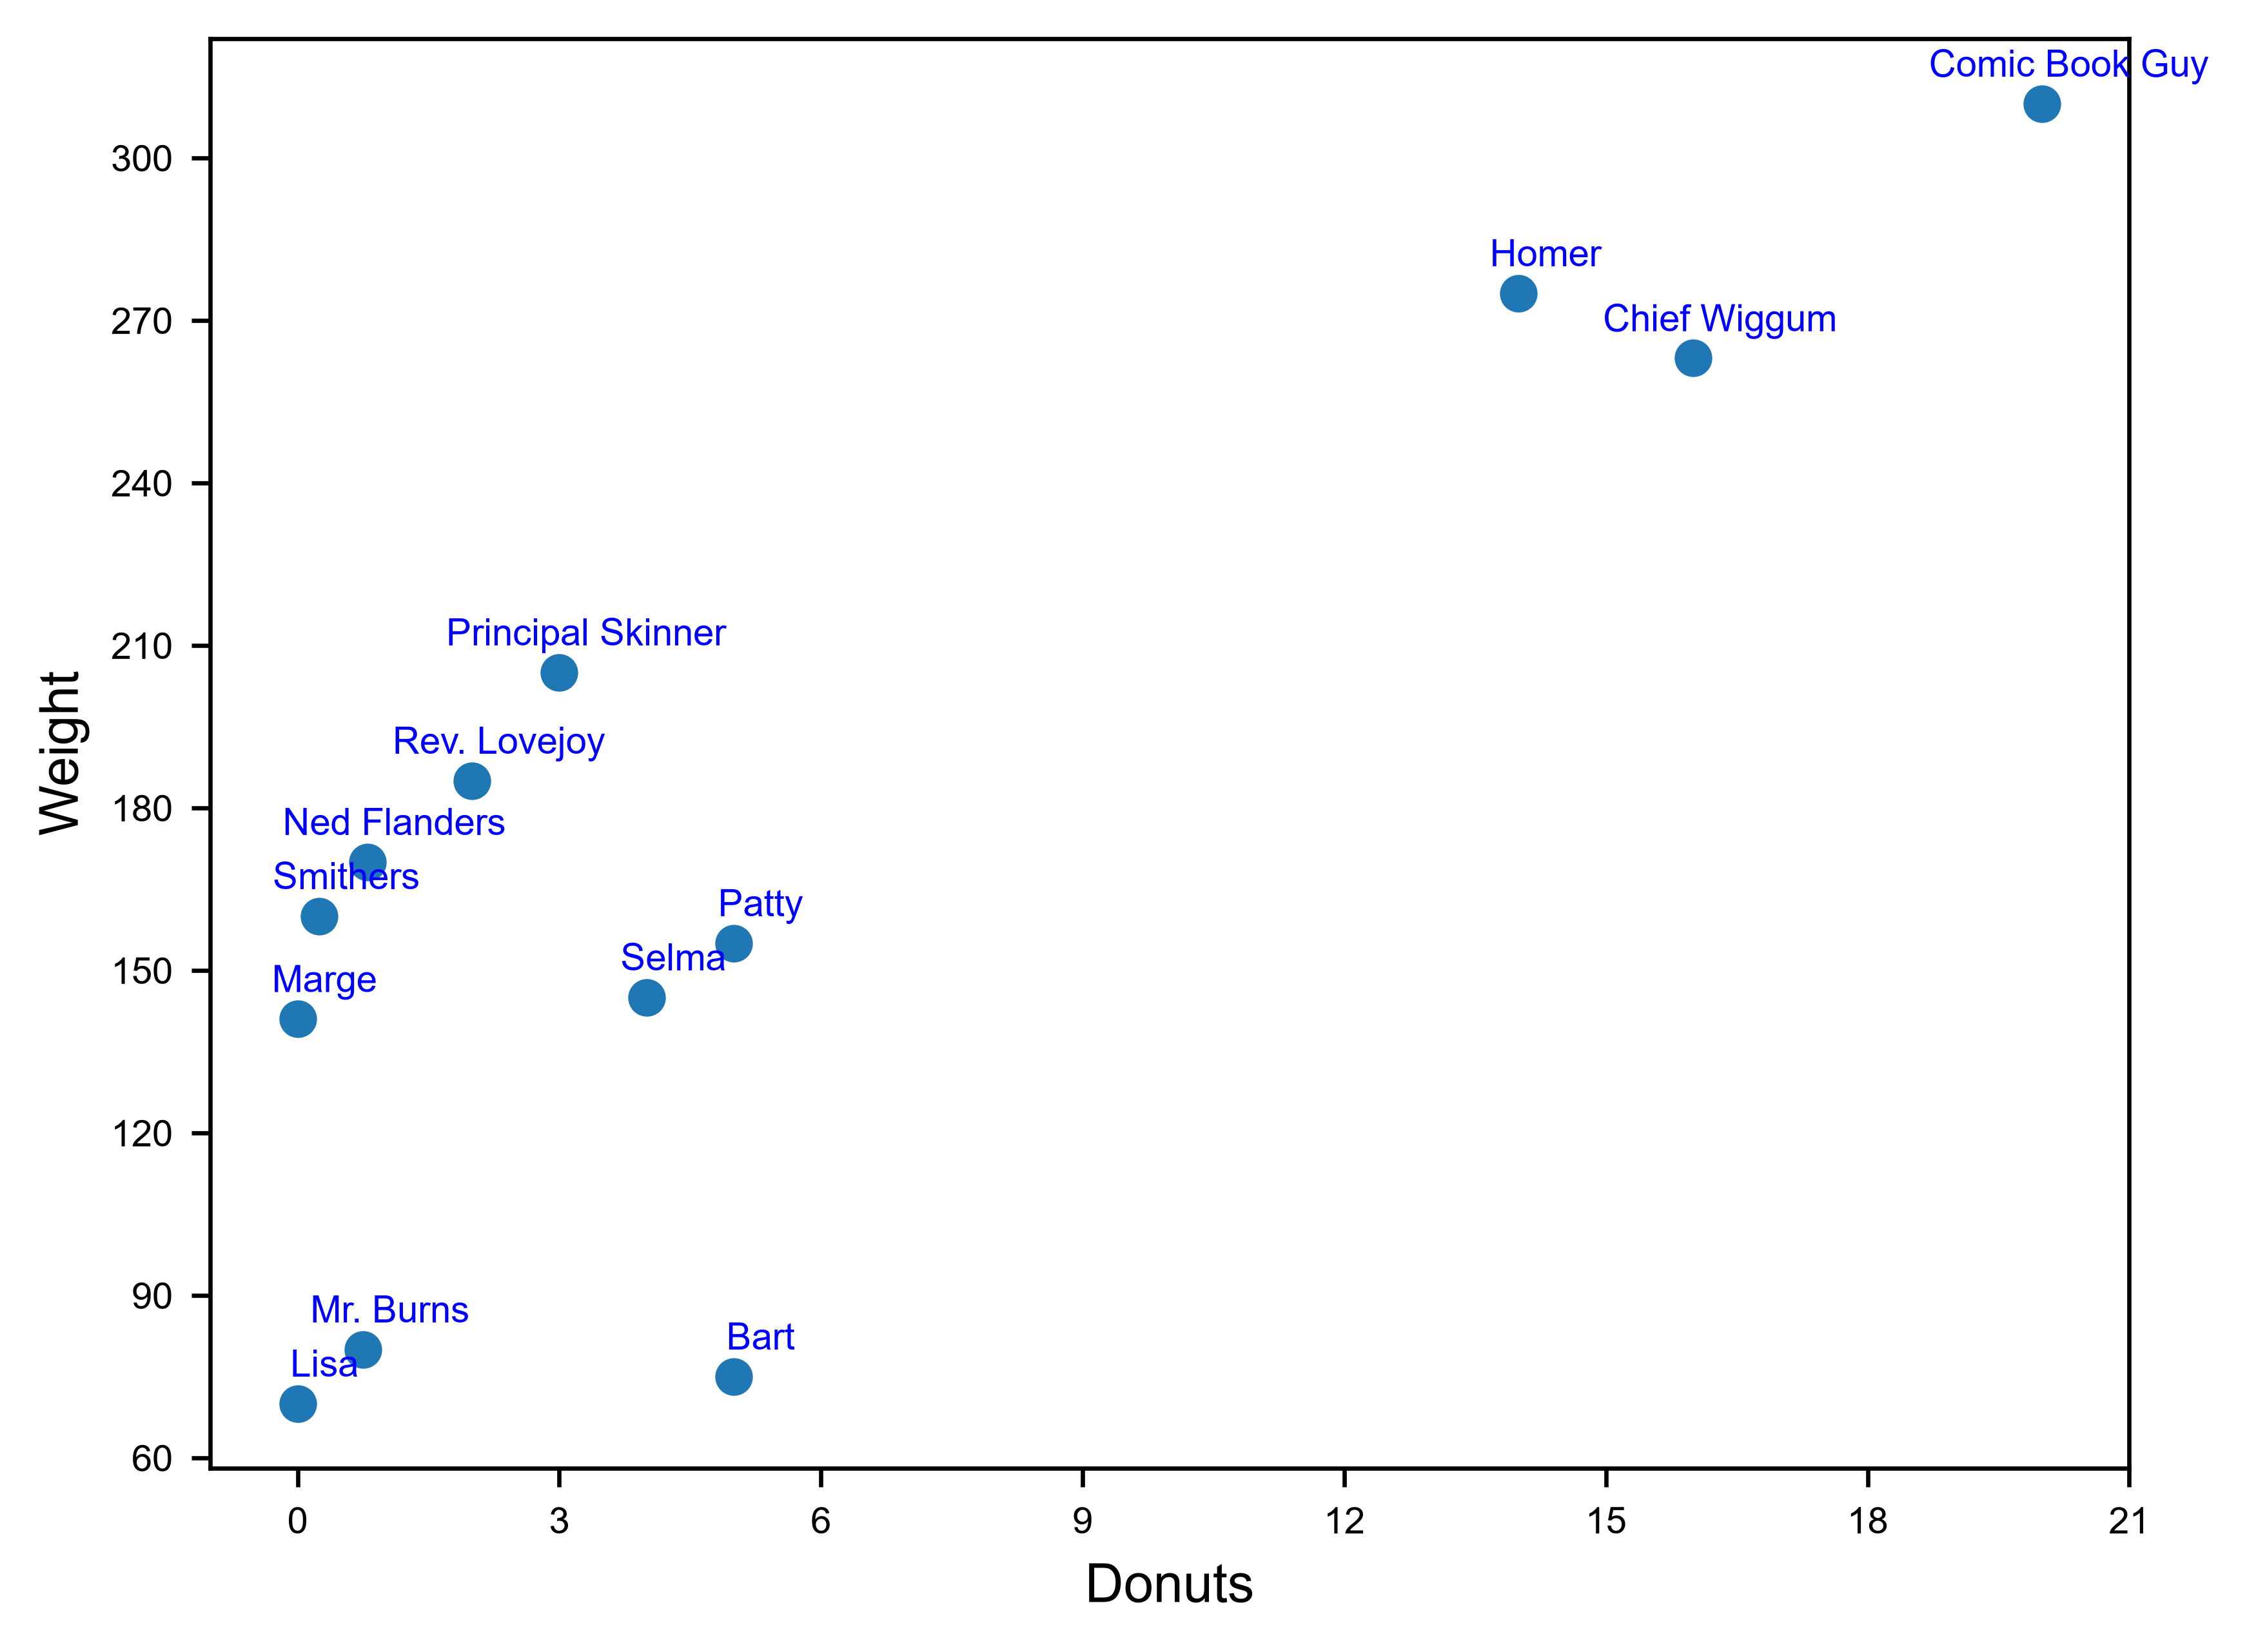

In [4]:
fig, ax = plt.subplots(dpi=600)

ax.scatter(DonutDS["Donuts per week"], DonutDS["Weight"])

ax.set_xlabel("Donuts")
ax.set_ylabel("Weight")

for _, row in DonutDS.iterrows():
    ax.annotate(row["Name"],
        (row["Donuts per week"], row["Weight"]),
        xytext=(5,5), ha="center",
        textcoords="offset points",
        color="Blue",
        fontsize=7
    )

ax.tick_params(axis="both", labelsize=7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

### Figure 1.3

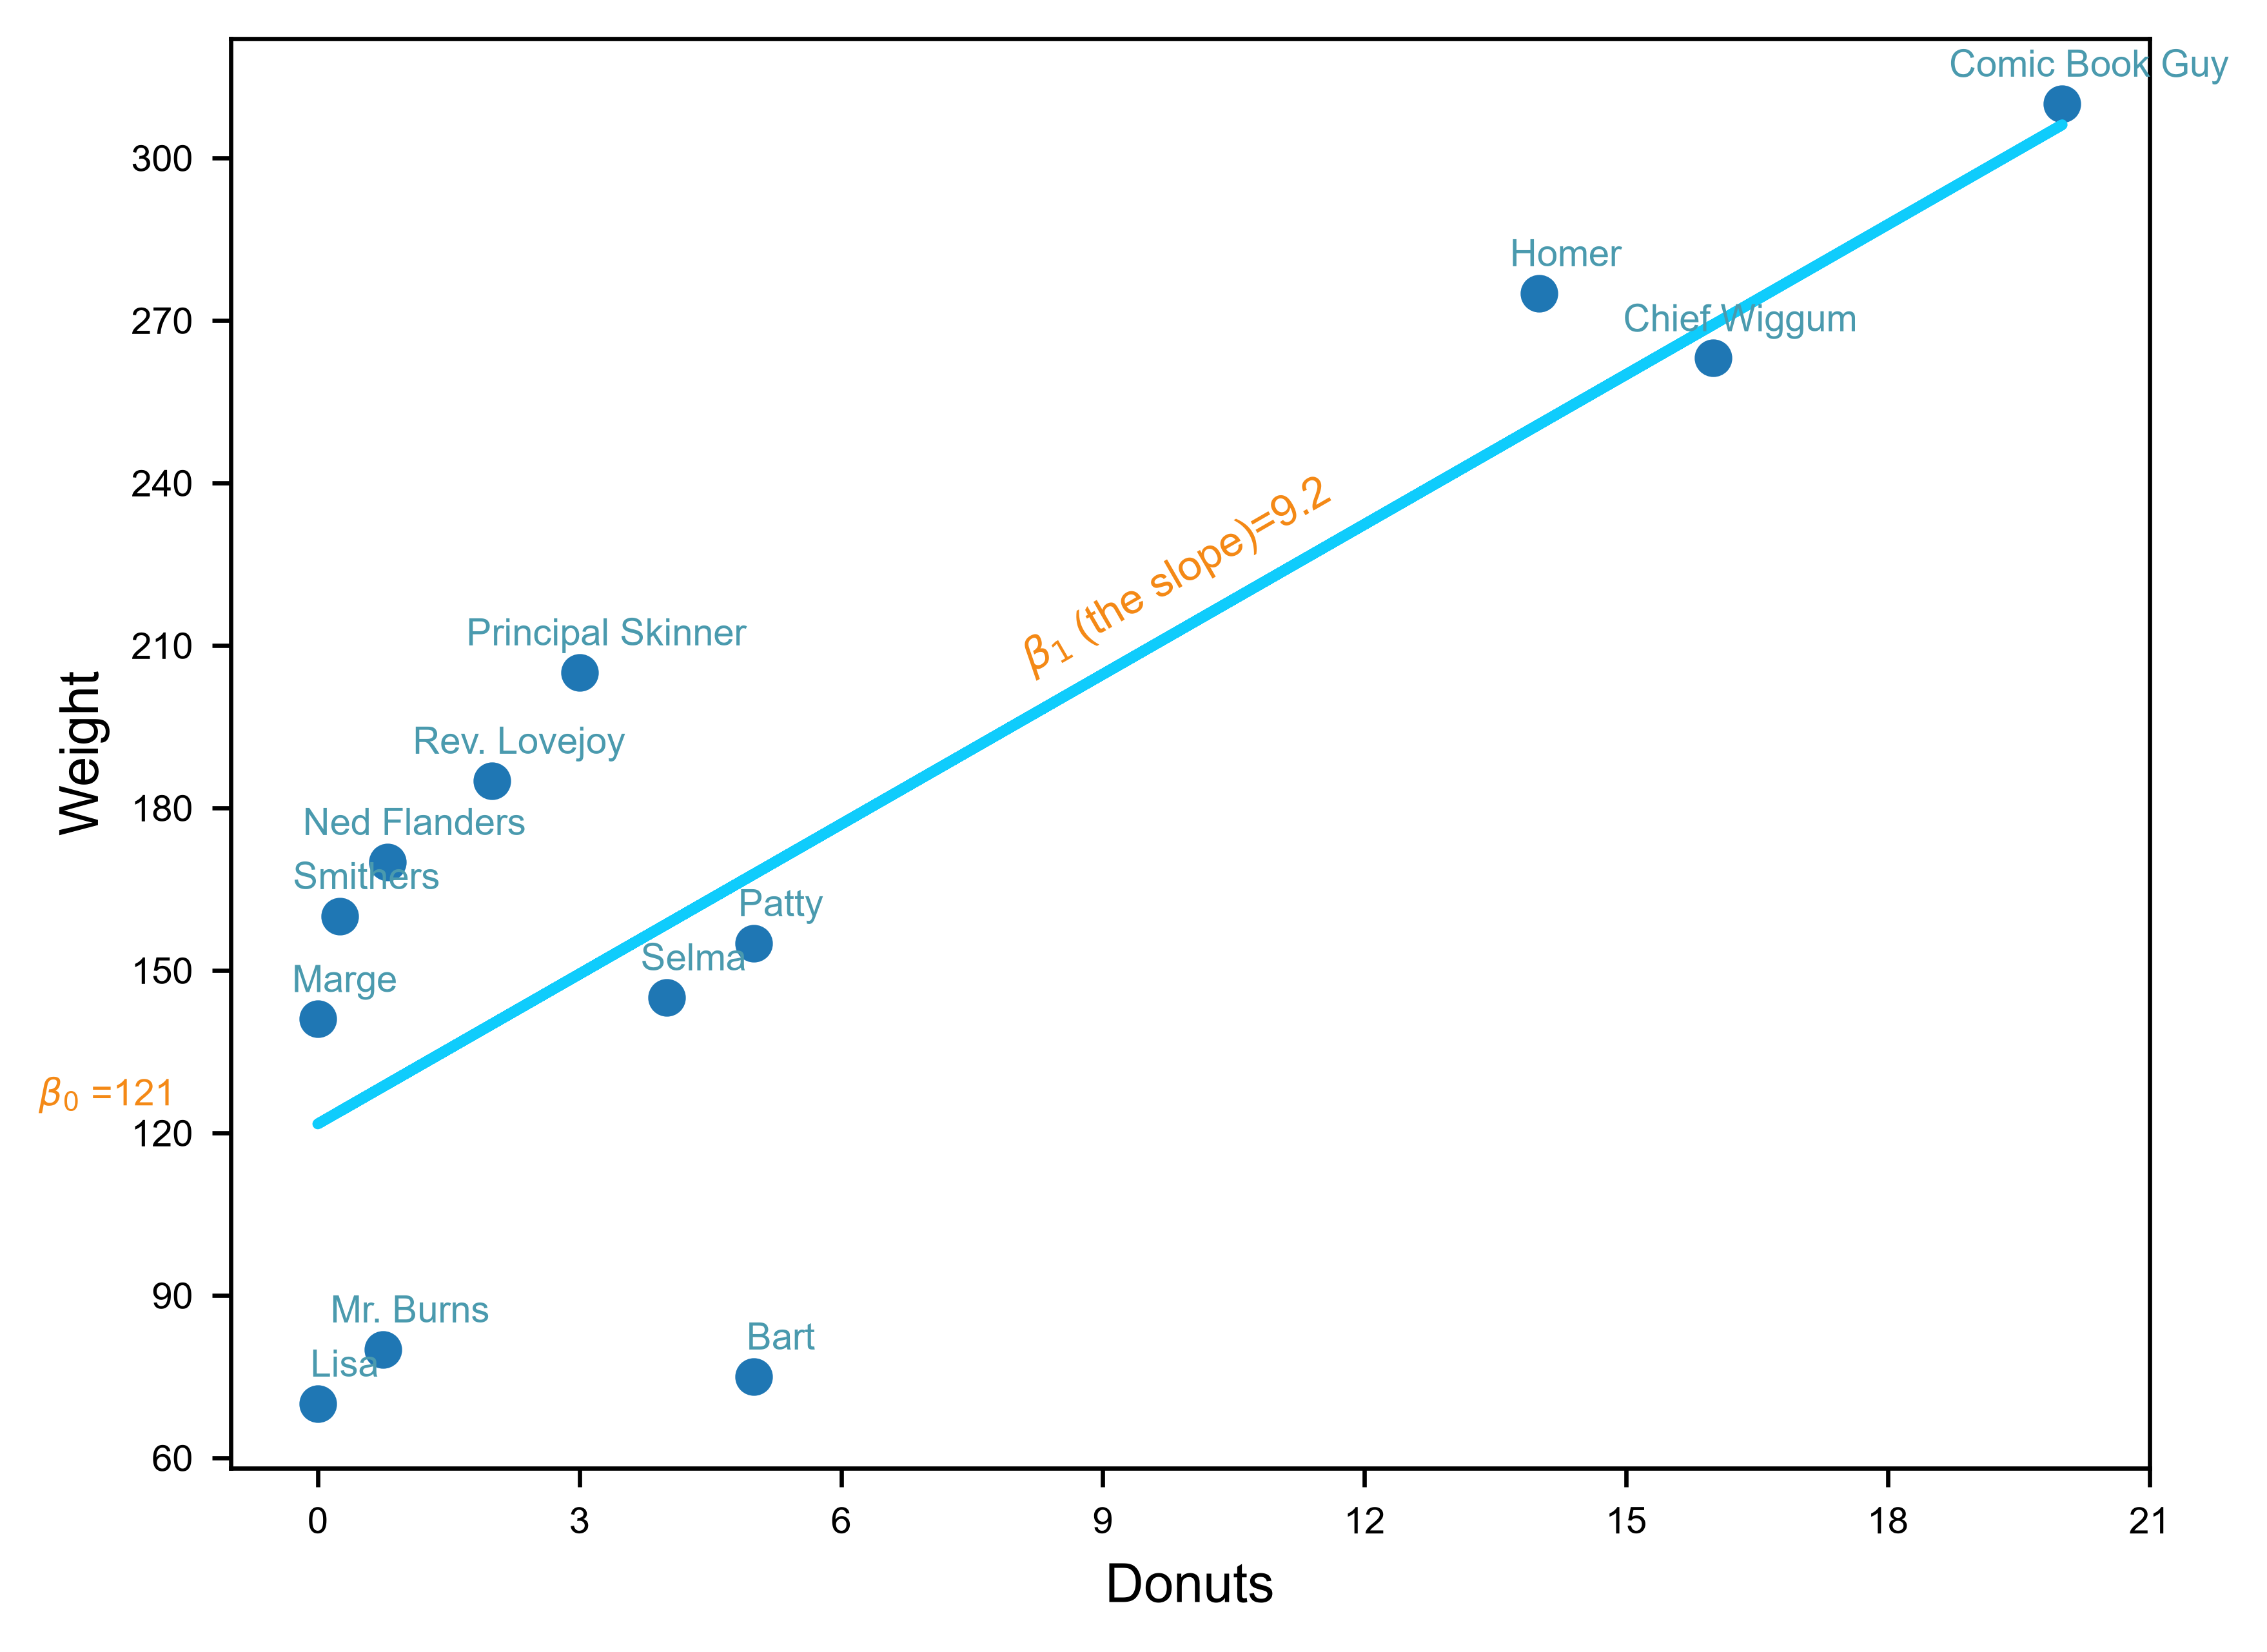

In [5]:
fig, ax = plt.subplots(dpi=600)

ax.scatter(DonutDS["Donuts per week"], DonutDS["Weight"])

ax.set_xlabel("Donuts")
ax.set_ylabel("Weight")

for _, row in DonutDS.iterrows():
    ax.annotate(row["Name"],
        (row["Donuts per week"], row["Weight"]),
        xytext=(5,5), ha="center",
        textcoords="offset points",
        color="#4A9AAE",
        fontsize=7
    )

ax.tick_params(axis="both", labelsize=7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#line
x = DonutDS["Donuts per week"]
y = DonutDS["Weight"]
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color="#0FCCFC", linewidth=2)

ax.text(8,205,r'$\beta_1$ (the slope)=9.2',rotation=30, color="#F48916", fontsize=8)
ax.text(-3.2,125,r"$\beta_0$ " + "=121",rotation=0, color="#F48916", fontsize=7)

plt.show()

### Our slope and intercept

In [6]:
print(m)
print(b)

9.223525902286609
121.61341277831602


### Figure 1.4

Some part of the code is taken from [matplotlib cheatsheet](https://matplotlib.org/cheatsheets/)

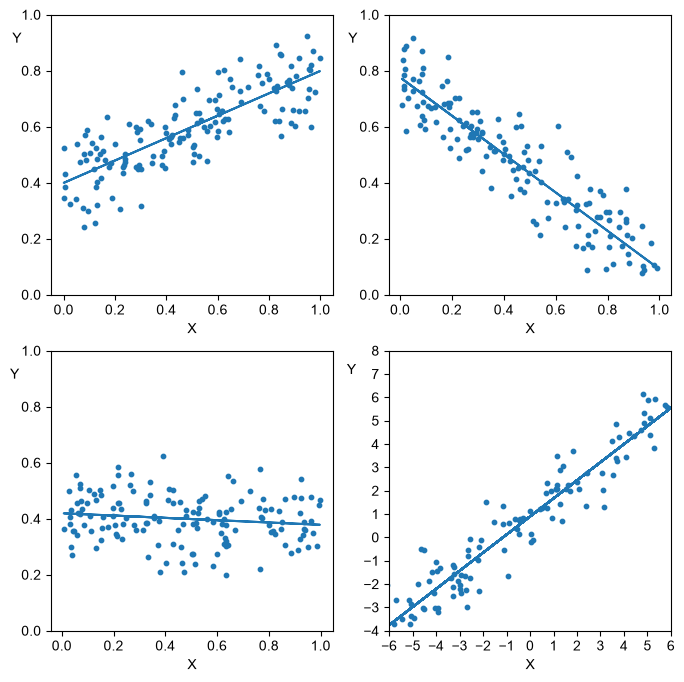

In [10]:
fig, axes= plt.subplots(2,2, figsize=(8,8))
np.random.seed(23)

ax=axes[0][0]

#First we generate some x values, this is just simulation, rand automatically generates using uniform distribution between 0 and 1
x= np.random.rand(150)
#I know that the line starts from 0.4 and then slope of 0.4 is a visual guess
#I then want some errors, i.e. I want y to have some spread which is normally distributed and for that I introduce ϵ = normal distribution, with standard deviation of 0.09, one can play with this value to see what looks the best
y=0.4+0.4*x+np.random.normal(0, 0.09, 150)

#We run our regression by using ploynomial fitting
m, b = np.polyfit(x, y, 1)

#We plot
ax.scatter(x,y, s=10)
ax.plot(x,m*x+b)

#For labels
ax.set_xlabel("X")
ax.text(-0.2,0.90,"Y", rotation=0 )
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(0,1)

ax=axes[0][1]
x= np.random.rand(150)
y=0.8-0.7*x+np.random.normal(0, 0.09, 150)

#We run our regression by using ploynomial fitting
m, b = np.polyfit(x, y, 1)

#We plot
ax.scatter(x,y, s=10)
ax.plot(x,m*x+b)

#For labels
ax.set_xlabel("X")
ax.text(-0.2,0.90,"Y", rotation=0 )
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(0,1)

ax=axes[1][0]
x= np.random.rand(150)
y=0.4+0*x+np.random.normal(0, 0.09, 150)

#We run our regression by using ploynomial fitting
m, b = np.polyfit(x, y, 1)

#We plot
ax.scatter(x,y, s=10)
ax.plot(x,m*x+b)

#For labels
ax.set_xlabel("X")
ax.text(-0.2,0.90,"Y", rotation=0 )
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(0,1)

ax=axes[1][1]

x= np.random.uniform(-8,8,150)
#since now my values tend form -8 to 8 we take into account that -8 and set our intercept at 1
y=1+0.8*x+np.random.normal(0, 0.8, 150)

#We run our regression by using ploynomial fitting
m, b = np.polyfit(x, y, 1)

#We plot
ax.scatter(x,y, s=10)
ax.plot(x,m*x+b)

#For labels
ax.set_xlabel("X")
ax.text(-7.8,7,"Y", rotation=0 )
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xlim(-6,6)
ax.set_ylim(-4,8)

plt.show()

### Figure 1.5

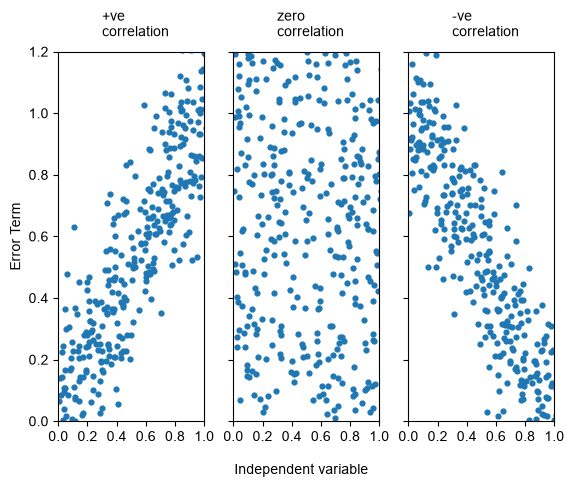

In [12]:
fig, axes= plt.subplots(1,3, sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.2, hspace=0)
fig.text(0.4,-0.0, "Independent variable")
np.random.seed(42)

ax=axes[0]
x = np.random.uniform(0,1.2,400)
y = x + np.random.normal(0, 0.17, 400)
ax.scatter(x, y, s=12)
ax.text(0.3,1.25,"+ve \ncorrelation")
ax.set_ylabel("Error Term")
ax.set_xlim(0,1)
ax.set_ylim(0,1.2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

ax=axes[1]
x1 = np.random.uniform(0,1.2,400)
y1= np.random.uniform(0,1.2,400)
ax.scatter(x1, y1, s=12)
ax.text(0.3,1.25,"zero \ncorrelation")
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

ax=axes[2]
x3 = np.random.uniform(0,1.2,400)
y3 = 1 - x3 + np.random.normal(0, 0.17, 400)
ax.scatter(x3, y3, s=12)
ax.text(0.3,1.25,"-ve \ncorrelation")
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

plt.show()


### Figure 1.6

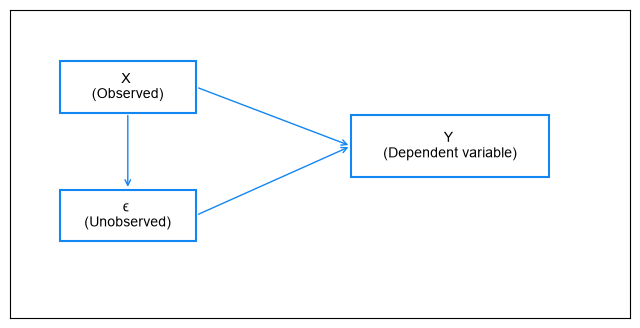

In [23]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(8,4))

# Remove axes
ax.set_xlim(0,10)
ax.set_ylim(0,6)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.tick_params(axis="both", which="major", length=0)


# Box
ax.add_patch(Rectangle((0.8,4), 2.2, 1,
                       fill=False, linewidth=1.5, color="#1286F3"))
ax.text(1.9,4.5, "X \n(Observed)",
        ha="center", va="center")

# Error box
ax.add_patch(Rectangle((0.8,1.5),2.2,1,
                       fill=False, linewidth=1.5, color="#1286F3"))
ax.text(1.9,2, "ϵ \n(Unobserved)",
        ha="center", va="center")

# Y box
ax.add_patch(Rectangle((5.5,2.75),3.2,1.2,
                       fill=False, linewidth=1.5, color="#1286F3"))
ax.text(7.1,3.35,"Y \n(Dependent variable)",
        ha="center", va="center")

# X -> epsilon
ax.annotate("",                         # We just want the arrow so empty string
            xy=(1.9,2.5),               #Tail of the arrow
            xytext=(1.9,4),             #Head of the arrow
            arrowprops=dict(arrowstyle="->", color="#1286F3"))

# X -> Y
ax.annotate("",
            xy=(5.5,3.35),
            xytext=(3,4.5),
            arrowprops=dict(arrowstyle="->", color="#1286F3"))

# epsilon -> Y
ax.annotate("",
            xy=(5.5,3.35),
            xytext=(3,2),
            arrowprops=dict(arrowstyle="->",color="#1286F3"))

plt.show()

### Figure 1.7

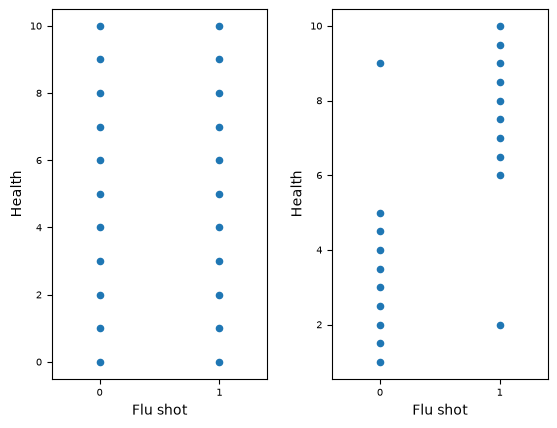

In [ ]:
fig, axes= plt.subplots(1,2)
fig.subplots_adjust(wspace=0.3)


flu_a= pd.DataFrame({"Flu shot": np.concatenate((np.zeros(11),np.ones(11))),
                     "Health" : np.concatenate((np.arange(0,11),np.arange(0,11) ))
                                                                 
})

flu_b = pd.DataFrame({
    "Flu shot": np.concatenate((np.zeros(10), np.ones(10))),
    "Health": np.concatenate((
        [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 9],
        [2, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10]
    ))
})


flu_a.plot.scatter("Flu shot", "Health", ax= axes[0])
flu_b.plot.scatter("Flu shot", "Health", ax= axes[1])

ax= axes[0]
ax.set_xlim(-0.4, 1.4)
ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.tick_params(axis="both", which="major" ,labelsize=7)

ax= axes[1]
ax.set_xlim(-0.4, 1.4)
ax.xaxis.set_major_locator(ticker.FixedLocator([0,1]))
ax.tick_params(axis="both", which="major" ,labelsize=7)

plt.show()

